In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)
print(f"running on {device}")

vgg = models.vgg19(weights = models.VGG19_Weights.DEFAULT).features.to(device)
vgg.eval()

for param in vgg.parameters():
    param.requires_grad = False

for name, layer in vgg._modules.items():
    print(name, layer)


13.0
running on cuda
0 Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1 ReLU(inplace=True)
2 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3 ReLU(inplace=True)
4 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5 Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6 ReLU(inplace=True)
7 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 ReLU(inplace=True)
9 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10 Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11 ReLU(inplace=True)
12 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13 ReLU(inplace=True)
14 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
15 ReLU(inplace=True)
16 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
17 ReLU(inplace=True)
18 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
19 Conv2d(256, 51

In [2]:
content_layer = '21'

style_layers = {
    '0':  'conv1_1',
    '5':  'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '28': 'conv5_1',
}

def get_features(image, model):
    features = {}
    x = image
    content_embed = None
    for name, layer in model._modules.items():
        x = layer(x)
        if name in style_layers.keys():
            features[style_layers[name]] = x
        if name == content_layer:
            content_embed = x
    return features, content_embed

def get_gram(features):
    matrices = {}
    for name, layer in features.items():
        b, n, h, w = layer.shape
        layer = layer.squeeze(0)
        layer = layer.reshape(n, h * w)
        gram = torch.mm(layer, layer.t())
        matrices[name] = gram.div(n * h * w)

    return matrices

def loss_fn(y_hat_embed, y_hat_feat, content_embed, style_grams, style_weight = 1.0):
    y_hat_grams = get_gram(y_hat_feat)
    L_content = F.mse_loss(y_hat_embed, content_embed)
    style_weights = {'conv1_1': 20.0, 'conv2_1': 1.3, 'conv3_1': 2.8, 'conv4_1': 0.8, 'conv5_1': 0.3}
    L_style = sum(style_weights[layer] * F.mse_loss(y_hat_grams[layer], style_grams[layer]) for layer in style_grams)

    return L_content + style_weight * L_style, L_content, L_style


100%|██████████| 300/300 [00:17<00:00, 16.87it/s]


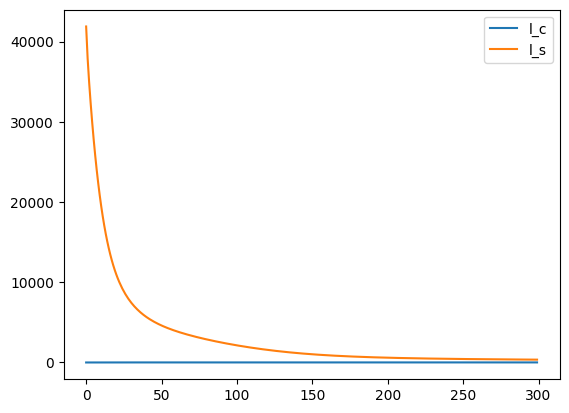

In [9]:
content_path = '../im/im/streetside'
style_path = '../im/im/dream'
style_weight = 100000000

epochs = 300

def load_image(path, size=512):
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    try:
        image = Image.open(path + ".png").convert('RGB')
    except:
        image = Image.open(path + ".jpg").convert('RGB')
    return transform(image).unsqueeze(0)  # add batch dim -> (1, C, H, W)

content = load_image(content_path).to(device)
style = load_image(style_path).to(device)

c_feats, c_embed = get_features(content, vgg)
s_feats, s_embed = get_features(style, vgg)
s_grams = get_gram(s_feats)

generated = content.clone().to(device).requires_grad_(True)
# generated = (torch.randn_like(content) * 0.01).to(device).requires_grad_(True)

fig, ax = plt.subplots()

lc = []
ls = []

optimizer = torch.optim.Adam([generated], lr=0.02)

for i in tqdm(range(epochs)):
    optimizer.zero_grad()
    g_feats, g_embed = get_features(generated, vgg)
    loss, l_c, l_s = loss_fn(g_embed, g_feats, c_embed, s_grams, style_weight=style_weight)
    lc.append(l_c.item())
    ls.append(l_s.item() * style_weight)
    loss.backward()
    optimizer.step()

ax.plot(lc, label="l_c")
ax.plot(ls, label="l_s")

plt.legend()
plt.show()

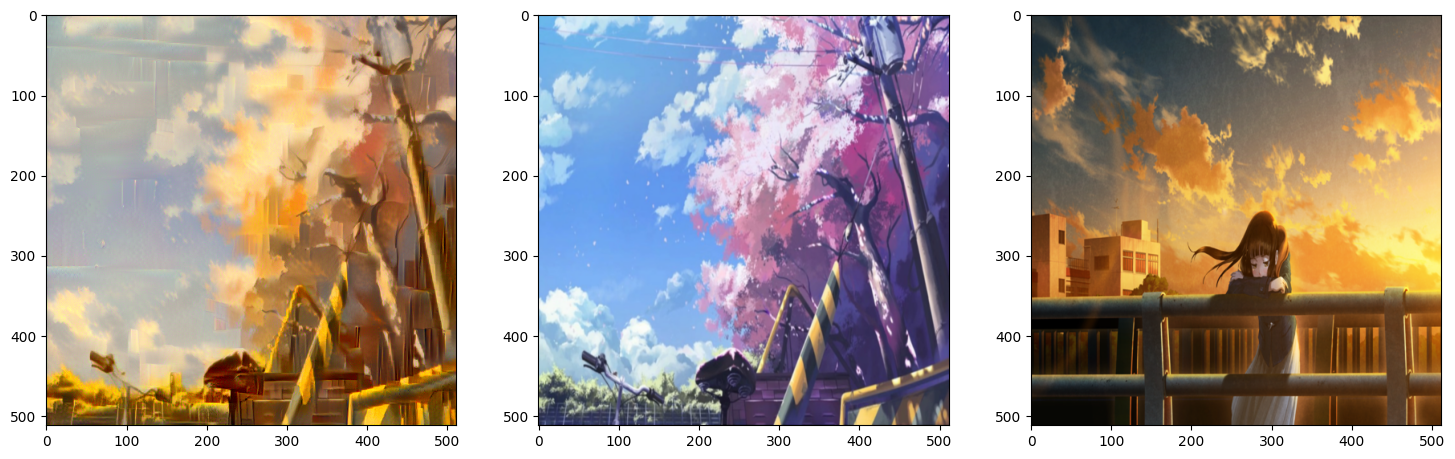

In [10]:
fig, ax = plt.subplots(1, 3, figsize = (18, 27))

unnorm = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
img = unnorm(generated.detach().squeeze(0)).clamp(0, 1)
img = img.permute(1, 2, 0).cpu().numpy()  # (C,H,W) -> (H,W,C)

# unnorm(style.cpu().squeeze(0)).permute(1, 2, 0)

ax[0].imshow(img)
ax[1].imshow(unnorm(content.cpu().squeeze(0)).permute(1, 2, 0))
ax[2].imshow(unnorm(style.cpu().squeeze(0)).permute(1, 2, 0))

plt.show()

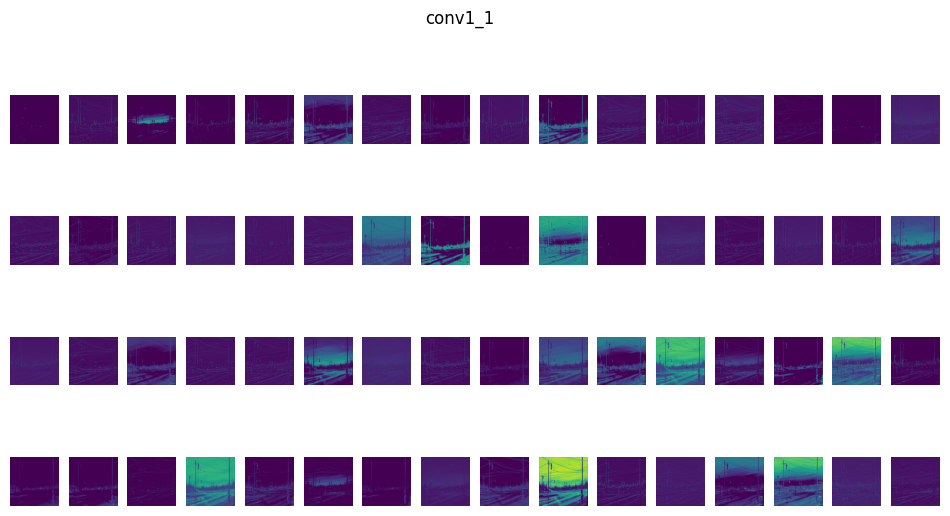

In [ ]:
def viz_features(features, layer_name, n_filters=16):
    feat = features[layer_name].detach().cpu()  # (1, C, H, W)
    fig, axes = plt.subplots(4, feat.shape[1]//4, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(feat[0, i].numpy(), cmap='viridis')
        ax.axis('off')
    plt.suptitle(layer_name)
    plt.show()

viz_features(s_feats, 'conv1_1')